# Projeto de Bloco - TP1

**Disciplina:** Projeto de Bloco: Análise e Segurança de Agentes de IA

**Professor:** Tiago Cariolano de Souza Xavier

**Grupo:** Bernardo de Moraes Eleuterio, Felipe Roberto Rocha, Guilherme Valentim Ramalho da Silva e Heitor Cella Oliveira


# 1. Documentação do Dataset

### Fonte (origem do dataset)

- **Nome:** Customer Support Ticket Dataset
- **Autor/Mantenedor no Kaggle:** [suraj520](https://www.kaggle.com/suraj520)
- **Link:** https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset

### Principais características

- Cada linha representa **um chamado (ticket)** aberto por um cliente.
- Contém **8.469 amostras** com **17 colunas**, combinando dados demográficos do cliente, dados do produto, texto livre (descrição do problema) e metadados operacionais do atendimento (canal, prioridade, status, tempos de resposta/resolução, satisfação).
- A coluna **`Ticket Description`** é a coluna de **texto livre** escrita pelo "cliente" descrevendo o problema/solicitação.
- A coluna **`Ticket Type`** é a coluna de **categoria/intenção** do chamado, com 5 valores possíveis: `Technical issue`, `Billing inquiry`, `Cancellation request`, `Product inquiry`, `Refund request`.

### Motivo da escolha do dataset

O dataset foi escolhido por conter milhares de exemplos reais de tickets de suporte, unindo o texto escrito pelo cliente à categoria do problema. Ele oferece exatamente a matéria-prima que o nosso sistema precisa para aprender a ler uma mensagem, identificar a intenção real do usuário (como suporte técnico ou cobrança) e rotear o chamado de forma automática e eficiente.


# 2. Importação de Bibliotecas e Carregamento dos Dados

In [8]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

CAMINHOS_POSSIVEIS = [
    "customer_support_tickets.csv",
    "../data/customer_support_tickets.csv",
    "data/customer_support_tickets.csv",
]

caminho_csv = next((c for c in CAMINHOS_POSSIVEIS if os.path.exists(c)), None)
if caminho_csv is None:
    raise FileNotFoundError(
        "customer_support_tickets.csv não encontrado. Caminhos testados: "
        + ", ".join(CAMINHOS_POSSIVEIS)
    )

df = pd.read_csv(caminho_csv)
print(f"Dataset carregado de: {caminho_csv}  ->  {df.shape[0]} linhas x {df.shape[1]} colunas")


def print_formatado(*args, largura_total=100):
    titulo = " ".join(str(a) for a in args)
    print("\n")
    print("=" * largura_total)
    print(titulo)
    print("=" * largura_total)

Dataset carregado de: ../data/customer_support_tickets.csv  ->  8469 linhas x 17 colunas


# 3. Compreensão do Problema e do Dataset

**Domínio do problema:** o sistema de atendimento ao cliente foi construído para entender a partir de uma mensagem enviada pelo cliente, **qual é a intenção do chamado** (é um problema técnico? uma dúvida sobre cobrança? um pedido de cancelamento? uma dúvida sobre produto? um pedido de reembolso?), para então poder rotear/priorizar o atendimento ou, futuramente, automatizar respostas.

**Exemplo do domínio do problema:**

| Mensagem (`Ticket Description`, resumida) | Intenção esperada (`Ticket Type`) |
|---|---|
| "My {product} is making strange noises and not functioning properly..." | Refund request |
| "I've forgotten my password for my {product} account..." | Technical issue |
| "I'm facing a recurring issue with my {product} where it..." | Cancellation request |

# 4. Inspeção Inicial

In [9]:
print_formatado("1. Tamanho do dataset:")
print(df.shape)

print_formatado("2. Variáveis do dataset:")
print(df.columns.tolist())

print_formatado("3. Significado das colunas:")
print("Ver célula Markdown a seguir.")

print_formatado("4. Tipos dos dados:")
print(df.dtypes)

print_formatado("5. Organização dos registros:")
df.info()

print_formatado("6. Exemplos de valores:")
print("\nPrimeiros registros:")
display(df.head())

print("\nÚltimos registros:")
display(df.tail())

print("\nRegistros aleatórios:")
display(df.sample(5, random_state=1))

print_formatado("7. Identificação das variáveis")
print("\nVariáveis numéricas:")
print(df[["Customer Age", "Customer Satisfaction Rating"]].describe())

print("\nVariáveis categóricas (quantidade de categorias únicas):")
colunas_categoricas = ["Ticket Type", "Ticket Subject", "Ticket Status",
                        "Ticket Priority", "Ticket Channel", "Customer Gender"]
for coluna in colunas_categoricas:
    print(f"{coluna:<20}: {df[coluna].nunique()} categorias -> {df[coluna].unique().tolist()}")

print("\nVariáveis textuais (texto livre, alta cardinalidade):")
for coluna in ["Customer Name", "Customer Email", "Ticket Description", "Resolution"]:
    print(f"{coluna:<20}: {df[coluna].nunique()} valores únicos de {df[coluna].notnull().sum()} não nulos")

print("\nVariáveis temporais (datas/horários em formato texto):")
for coluna in ["Date of Purchase", "First Response Time", "Time to Resolution"]:
    print(f"{coluna:<20}: exemplo -> {df[coluna].dropna().iloc[0]}")

print("\nVariável identificadora:")
print(f"Ticket ID: {df['Ticket ID'].nunique()} valores únicos de {len(df)} registros (identificador único, não é feature)")


print_formatado("8. Variáveis relevantes para o objetivo da análise")
print("Ver célula Markdown a seguir.")


print_formatado("9. Possíveis problemas nos dados")
print("Ver célula Markdown a seguir.")




1. Tamanho do dataset:
(8469, 17)


2. Variáveis do dataset:
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


3. Significado das colunas:
Ver célula Markdown a seguir.


4. Tipos dos dados:
Ticket ID                         int64
Customer Name                       str
Customer Email                      str
Customer Age                      int64
Customer Gender                     str
Product Purchased                   str
Date of Purchase                    str
Ticket Type                         str
Ticket Subject                      str
Ticket Description                  str
Ticket Status                       str
Resolution                          str
Ticket Priority                     str
Ticket Cha

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0



Últimos registros:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaN,NaN,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaN,NaN,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0
8468,8469,Steven Davis MD,lori20@example.net,53,Other,Philips Hue Lights,2020-06-01,Billing inquiry,Hardware issue,There seems to be a hardware problem with my {...,Open,NaN,High,Phone,NaN,NaN,NaN



Registros aleatórios:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
1825,1826,Angela Humphrey,joshua84@example.com,55,Female,Bose SoundLink Speaker,2021-06-11,Billing inquiry,Hardware issue,I'm having an issue with the {product_purchase...,Closed,Any because size far record.,High,Chat,2023-06-01 17:06:29,2023-06-01 06:25:29,2.0
473,474,James Escobar,huertaryan@example.com,32,Male,Adobe Photoshop,2021-10-08,Technical issue,Hardware issue,I'm having an issue with the {product_purchase...,Open,NaN,Medium,Phone,NaN,NaN,NaN
3509,3510,Daniel Mccullough,davidcox@example.com,61,Male,Adobe Photoshop,2021-02-16,Refund request,Product recommendation,I'm encountering a software bug in the {produc...,Open,NaN,Critical,Chat,NaN,NaN,NaN
5415,5416,Nicole Knight,johnhess@example.com,46,Female,Bose QuietComfort,2020-08-20,Refund request,Software bug,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,High,Chat,2023-06-01 13:49:59,NaN,NaN
5537,5538,Jessica Chase,wschwartz@example.com,45,Female,Samsung Galaxy,2021-02-02,Technical issue,Software bug,I'm having an issue with the {product_purchase...,Closed,Debate wife window kitchen inside tonight give...,Low,Phone,2023-05-31 23:53:47,2023-06-01 13:18:47,2.0




7. Identificação das variáveis

Variáveis numéricas:
       Customer Age  Customer Satisfaction Rating
count   8469.000000                   2769.000000
mean      44.026804                      2.991333
std       15.296112                      1.407016
min       18.000000                      1.000000
25%       31.000000                      2.000000
50%       44.000000                      3.000000
75%       57.000000                      4.000000
max       70.000000                      5.000000

Variáveis categóricas (quantidade de categorias únicas):
Ticket Type         : 5 categorias -> ['Technical issue', 'Billing inquiry', 'Cancellation request', 'Product inquiry', 'Refund request']
Ticket Subject      : 16 categorias -> ['Product setup', 'Peripheral compatibility', 'Network problem', 'Account access', 'Data loss', 'Payment issue', 'Refund request', 'Battery life', 'Installation support', 'Software bug', 'Hardware issue', 'Product recommendation', 'Delivery problem', 'Display 

## Observações - Inspeção Inicial

### 3. Significado das colunas

| Coluna | Descrição | Tipo |
|---|---|---|
| `Ticket ID` | Identificador único do chamado | Identificador (numérico) |
| `Customer Name` | Nome do cliente | Textual |
| `Customer Email` | E-mail do cliente | Textual |
| `Customer Age` | Idade do cliente | Numérica |
| `Customer Gender` | Gênero do cliente (`Male`, `Female`, `Other`) | Categórica |
| `Product Purchased` | Produto adquirido pelo cliente | Categórica (42 categorias) |
| `Date of Purchase` | Data da compra do produto | Temporal |
| `Ticket Type` | **Variável-alvo**: tipo/intenção do chamado | Categórica (5 categorias) |
| `Ticket Subject` | Assunto específico do chamado | Categórica (16 categorias) |
| `Ticket Description` | **Texto livre** com a descrição do problema/solicitação do cliente | Textual |
| `Ticket Status` | Status atual do chamado (`Open`, `Closed`, `Pending Customer Response`) | Categórica |
| `Resolution` | Texto de resolução do chamado (só existe para chamados `Closed`) | Textual |
| `Ticket Priority` | Prioridade do chamado (`Low`, `Medium`, `High`, `Critical`) | Categórica |
| `Ticket Channel` | Canal de abertura do chamado (`Email`, `Phone`, `Chat`, `Social media`) | Categórica |
| `First Response Time` | Data/hora da primeira resposta ao cliente | Temporal |
| `Time to Resolution` | Data/hora em que o chamado foi resolvido | Temporal |
| `Customer Satisfaction Rating` | Nota de satisfação do cliente (1 a 5), só existe para chamados `Closed` | Numérica |

### 5. Organização dos registros

- O dataset possui **8.469 registros** e **17 colunas**, sem nenhuma coluna com `Non-Null Count` divergente de forma inesperada - os valores ausentes existem apenas em `Resolution`, `First Response Time`, `Time to Resolution` e `Customer Satisfaction Rating`.
- `Ticket ID` é sequencial de 1 a 8.469 e funciona apenas como identificador, não como variável explicativa.
- Os tipos de dados foram carregados pelo pandas majoritariamente como `object` (texto), inclusive colunas que são conceitualmente categóricas, numéricas ou datas - isso é tratado na etapa de Limpeza e Preparação.

### 8. Variáveis relevantes para o objetivo da análise

- Para o objetivo do projeto (entender a **intenção** do cliente a partir do **texto**), as colunas centrais são `Ticket Description` (texto) e `Ticket Type` (intenção/alvo).
- `Ticket Subject`, `Ticket Priority`, `Ticket Channel` e `Ticket Status` são rele vantes como contexto adicional do chamado.
- `Customer Name`, `Customer Email` e `Ticket ID` são identificadores/dados pessoais, sem valor preditivo, e devem ser tratados com cuidado de privacidade caso o dataset venha a ser reutilizado.

### 9. Possíveis problemas identificados na inspeção inicial

- Colunas que deveriam ser categóricas, numéricas ou de data estão como `object` (texto).
- Quatro colunas (`Resolution`, `First Response Time`, `Time to Resolution`, `Customer Satisfaction Rating`) possuem valores ausentes que precisam ser investigados na etapa de Verificação da Qualidade dos Dados.


# 5. Verificação da Qualidade dos Dados

In [10]:
print_formatado("1. Valores ausentes e em qual quantidade:")
print(df.isnull().sum())
print("\nPercentual de ausentes:")
print((df.isnull().mean() * 100).round(2))

print_formatado("2. Registros duplicados:")
print("Duplicatas completas:", df.duplicated().sum())
print("Duplicatas desconsiderando Ticket ID:", df.drop(columns=["Ticket ID"]).duplicated().sum())
print("Descrições (Ticket Description) duplicadas:", df["Ticket Description"].duplicated().sum())

print_formatado("3. Tipos dos dados estão corretos?")
print(df.dtypes)
print("Ver Markdown.")

print_formatado("4. Categorias escritas de formas diferentes:")
colunas_categoricas = ["Ticket Type", "Ticket Subject", "Ticket Status",
                        "Ticket Priority", "Ticket Channel", "Customer Gender"]
for coluna in colunas_categoricas:
    print(f"{coluna:<20}: valores -> {sorted(df[coluna].unique().tolist())}")

print_formatado("5. Textos vazios ou espaços extras:")
colunas_texto = colunas_categoricas + ["Customer Name", "Ticket Description"]
for coluna in colunas_texto:
    qtd_espacos = (df[coluna].astype(str) != df[coluna].astype(str).str.strip()).sum()
    qtd_vazios = (df[coluna].astype(str).str.strip() == "").sum()
    print(f"{coluna:<20}: espaços extras={qtd_espacos:<5} vazios={qtd_vazios}")

print_formatado("6. Valores impossíveis ou fora do contexto:")
qtd_placeholder = df["Ticket Description"].str.contains(r"\{product_purchased\}", regex=True).sum()
print(f"Tickets cujo texto contém literalmente o placeholder não substituído '{{product_purchased}}': "
      f"{qtd_placeholder} de {len(df)} ({qtd_placeholder / len(df) * 100:.1f}%)")

print_formatado("7. Erros de digitação ou preenchimento:")
print("Ver Markdown.")

print_formatado("8. Relação entre os valores ausentes e o Ticket Status:")
print("\nResolution ausente x Ticket Status:")
print(pd.crosstab(df["Ticket Status"], df["Resolution"].isnull()))
print("\nCustomer Satisfaction Rating ausente x Ticket Status:")
print(pd.crosstab(df["Ticket Status"], df["Customer Satisfaction Rating"].isnull()))
print("\nTime to Resolution ausente x Ticket Status:")
print(pd.crosstab(df["Ticket Status"], df["Time to Resolution"].isnull()))




1. Valores ausentes e em qual quantidade:
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

Percentual de ausentes:
Ticket ID                        0.00
Customer Name                    0.00
Customer Email                   0.00
Customer Age                     0.00
Customer Gender                  0.00
Product Purchased                0.00
Date of Purchase                 0.00
Ticket Type            

## Observações - Verificação da Qualidade dos Dados

### 1. Valores ausentes e em qual quantidade

- `Resolution`, `Time to Resolution` e `Customer Satisfaction Rating` têm exatamente **5.700 valores ausentes (67,3%)** cada.
- `First Response Time` tem **2.819 valores ausentes (33,3%)**.
- O cruzamento com `Ticket Status` (célula acima) mostra que **os valores ausentes não são aleatórios**: `Resolution`, `Time to Resolution` e `Customer Satisfaction Rating` só existem quando `Ticket Status == "Closed"`; e `First Response Time` só é nulo quando `Ticket Status == "Open"`. Ou seja, a ausência reflete o **estágio do atendimento** (chamado ainda não respondido/resolvido), e não um erro de coleta.

### 2. Registros duplicados

- Não há **nenhuma linha completamente duplicada** e nenhuma duplicata mesmo desconsiderando `Ticket ID`.
- Entretanto, **392 valores de `Ticket Description` se repetem** entre linhas diferentes. Isso é esperado em um dataset sintético gerado por template, e não representa um chamado duplicado (cada linha tem cliente, produto, canal etc. diferentes).

### 3. Tipos dos dados estão corretos?

- Não. Todas as colunas foram lidas como `object` (texto) pelo pandas, inclusive `Customer Age` (que já veio numérica), `Customer Satisfaction Rating` (numérica), as colunas categóricas e as colunas de data. Isso é corrigido na etapa de Limpeza.

### 4. Categorias escritas de forma diferente

- Não há inconsistência de capitalização/grafia nas colunas categóricas (`Ticket Type`, `Ticket Subject`, `Ticket Status`, `Ticket Priority`, `Ticket Channel`, `Customer Gender`) - cada uma tem exatamente as categorias esperadas.

### 5. Textos vazios ou espaços extras

- Não foram encontrados espaços extras nem valores vazios (`""`) em nenhuma das colunas textuais/categóricas verificadas.

### 6. Valores impossíveis ou fora do contexto

- 100% das descrições (`Ticket Description`) contêm o placeholder literal `{product_purchased}` **não substituído** pelo nome real do produto (ex.: *"I'm having an issue with the {product_purchased}. Please assist."*). Isso é uma falha de geração/preenchimento do texto sintético: o texto deveria trazer o nome do produto (ex. "GoPro Hero"), mas manteve o marcador do template.

### 7. Erros de digitação ou preenchimento

- Além do placeholder `{product_purchased}` citado acima, não foram identificados outros erros evidentes de digitação/preenchimento nas colunas estruturadas.

### Problemas que precisam ser corrigidos antes da análise

1. Converter colunas categóricas para o tipo `category`.
2. Converter `Customer Satisfaction Rating` para numérico (`float`) e as colunas de data para `datetime`.


# 6. Limpeza e Preparação dos Dados

In [11]:
print_formatado("1. Remover/tratar registros duplicados desnecessários:")
print(f"Duplicatas completas antes: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Duplicatas completas depois: {df.duplicated().sum()}")
print("(Nenhuma duplicata completa encontrada - nenhuma linha removida.)")

print_formatado("2. Remover/tratar valores ausentes de forma justificada:")
print("Mantidos como NaN: 'Resolution', 'First Response Time', 'Time to Resolution' e")
print("'Customer Satisfaction Rating', pois a ausência é estrutural (chamado ainda não")
print("respondido/resolvido), conforme demonstrado na verificação de qualidade.")
print("Nenhuma linha ou coluna removida por conta de valores ausentes.")

print_formatado("3. Corrigir tipos das colunas:")
colunas_categoricas = ["Ticket Type", "Ticket Subject", "Ticket Status",
                        "Ticket Priority", "Ticket Channel", "Customer Gender",
                        "Product Purchased"]
print("Tipos antes:")
print(df[colunas_categoricas + ["Customer Satisfaction Rating"]].dtypes)

for coluna in colunas_categoricas:
    df[coluna] = df[coluna].astype("category")

df["Customer Satisfaction Rating"] = pd.to_numeric(df["Customer Satisfaction Rating"])

for coluna in ["Date of Purchase"]:
    df[coluna] = pd.to_datetime(df[coluna])
for coluna in ["First Response Time", "Time to Resolution"]:
    df[coluna] = pd.to_datetime(df[coluna])

print("\nTipos depois:")
print(df[colunas_categoricas + ["Customer Satisfaction Rating", "Date of Purchase",
                                 "First Response Time", "Time to Resolution"]].dtypes)

print_formatado("4. Corrigir espaços, erros de preenchimento e inconsistências evidentes:")
print("Não foram encontrados espaços extras/inconsistências nas colunas categóricas (ver Markdown anterior).")

print_formatado("5. Corrigir valores inválidos:")
print("Não foram encontrados valores inválidos em Customer Age, Customer Satisfaction Rating ou Date of Purchase.")

print_formatado("Dataset após limpeza:")
print(df.shape)
df.info()




1. Remover/tratar registros duplicados desnecessários:
Duplicatas completas antes: 0
Duplicatas completas depois: 0
(Nenhuma duplicata completa encontrada - nenhuma linha removida.)


2. Remover/tratar valores ausentes de forma justificada:
Mantidos como NaN: 'Resolution', 'First Response Time', 'Time to Resolution' e
'Customer Satisfaction Rating', pois a ausência é estrutural (chamado ainda não
respondido/resolvido), conforme demonstrado na verificação de qualidade.
Nenhuma linha ou coluna removida por conta de valores ausentes.


3. Corrigir tipos das colunas:
Tipos antes:
Ticket Type                         str
Ticket Subject                      str
Ticket Status                       str
Ticket Priority                     str
Ticket Channel                      str
Customer Gender                     str
Product Purchased                   str
Customer Satisfaction Rating    float64
dtype: object

Tipos depois:
Ticket Type                           category
Ticket Subject     

## Observações - Limpeza e Preparação dos Dados

### 4. Corrigir espaços, erros de preenchimento e inconsistências evidentes

- Nenhuma inconsistência evidente foi corrigida, pois nenhuma foi encontrada.

### 5. Corrigir valores inválidos

- Não havia valores inválidos a corrigir.

### Resumo das operações de limpeza aplicadas

1. Nenhuma linha duplicada removida (não havia duplicatas completas).
2. Valores ausentes mantidos como `NaN`, por serem estruturais.
3. Colunas categóricas (`Ticket Type`, `Ticket Subject`, `Ticket Status`, `Ticket Priority`, `Ticket Channel`, `Customer Gender`, `Product Purchased`) convertidas para o tipo `category`.
4. `Customer Satisfaction Rating` convertida para tipo numérico.
5. `Date of Purchase`, `First Response Time` e `Time to Resolution` convertidas para `datetime`.


# 7. Análise Univariada

## Variáveis numéricas



1. Média, mediana, mínimo e máximo:

Variável 'Customer Age':
Média  : 44.03
Mediana: 44.00
Mínimo : 18
Máximo : 70

Variável 'Customer Satisfaction Rating':
Média  : 2.99
Mediana: 3.00
Mínimo : 1.0
Máximo : 5.0


2. Quartis, variância e desvio-padrão:

Variável 'Customer Age':
Q1 (25%): 31.00
Q2 (50%): 44.00
Q3 (75%): 57.00
Variância    : 233.97
Desvio-padrão: 15.30

Variável 'Customer Satisfaction Rating':
Q1 (25%): 2.00
Q2 (50%): 3.00
Q3 (75%): 4.00
Variância    : 1.98
Desvio-padrão: 1.41


3. Distribuição dos valores:

Variável 'Customer Age':
count    8469.000000
mean       44.026804
std        15.296112
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: Customer Age, dtype: float64


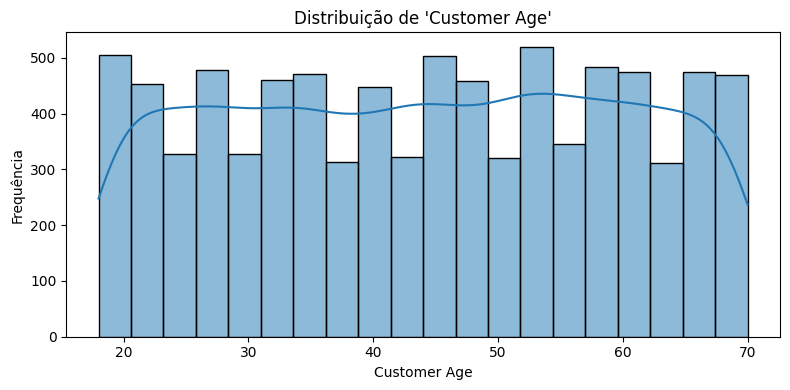


Variável 'Customer Satisfaction Rating':
count    2769.000000
mean        2.991333
std         1.407016
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Customer Satisfaction Rating, dtype: float64


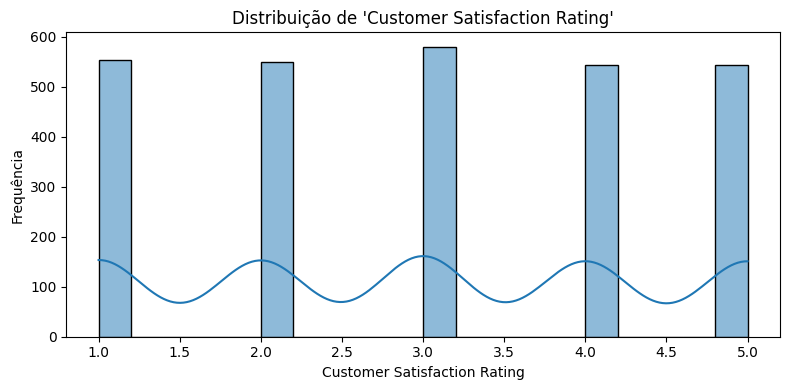

In [12]:
colunas_numericas = ["Customer Age", "Customer Satisfaction Rating"]

print_formatado("1. Média, mediana, mínimo e máximo:")
for coluna in colunas_numericas:
    print(f"\nVariável '{coluna}':")
    print(f"Média  : {df[coluna].mean():.2f}")
    print(f"Mediana: {df[coluna].median():.2f}")
    print(f"Mínimo : {df[coluna].min()}")
    print(f"Máximo : {df[coluna].max()}")

print_formatado("2. Quartis, variância e desvio-padrão:")
for coluna in colunas_numericas:
    q1 = df[coluna].quantile(0.25)
    q2 = df[coluna].quantile(0.50)
    q3 = df[coluna].quantile(0.75)
    print(f"\nVariável '{coluna}':")
    print(f"Q1 (25%): {q1:.2f}")
    print(f"Q2 (50%): {q2:.2f}")
    print(f"Q3 (75%): {q3:.2f}")
    print(f"Variância    : {df[coluna].var():.2f}")
    print(f"Desvio-padrão: {df[coluna].std():.2f}")

print_formatado("3. Distribuição dos valores:")
for coluna in colunas_numericas:
    print(f"\nVariável '{coluna}':")
    print(df[coluna].describe())

    plt.figure(figsize=(8, 4))
    sns.histplot(df[coluna].dropna(), kde=True, bins=20)
    plt.title(f"Distribuição de '{coluna}'")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()


## Variáveis categóricas



1. Quantidade de categorias:
Ticket Type         5
Ticket Subject     16
Ticket Status       3
Ticket Priority     4
Ticket Channel      4
Customer Gender     3
dtype: int64


2. Frequência absoluta e relativa:

Variável 'Ticket Type' - frequência absoluta:
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Variável 'Ticket Type' - frequência relativa (%):
Ticket Type
Refund request          20.69
Technical issue         20.63
Cancellation request    20.01
Product inquiry         19.38
Billing inquiry         19.29
Name: proportion, dtype: float64


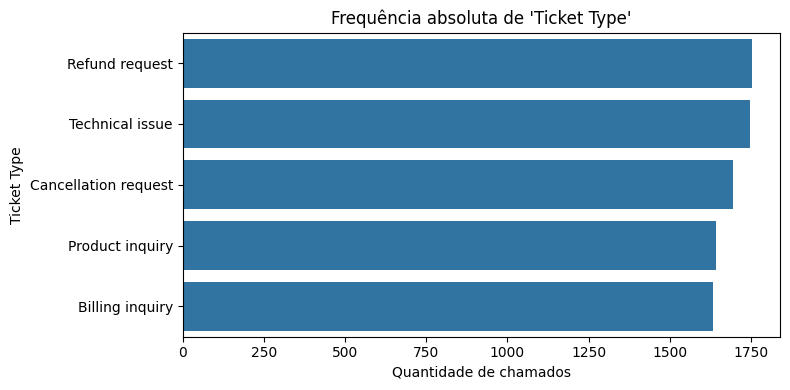


Variável 'Ticket Subject' - frequência absoluta:
Ticket Subject
Refund request              576
Software bug                574
Product compatibility       567
Delivery problem            561
Hardware issue              547
Battery life                542
Network problem             539
Installation support        530
Product setup               529
Payment issue               526
Product recommendation      517
Account access              509
Peripheral compatibility    496
Data loss                   491
Cancellation request        487
Display issue               478
Name: count, dtype: int64

Variável 'Ticket Subject' - frequência relativa (%):
Ticket Subject
Refund request              6.80
Software bug                6.78
Product compatibility       6.70
Delivery problem            6.62
Hardware issue              6.46
Battery life                6.40
Network problem             6.36
Installation support        6.26
Product setup               6.25
Payment issue               6.2

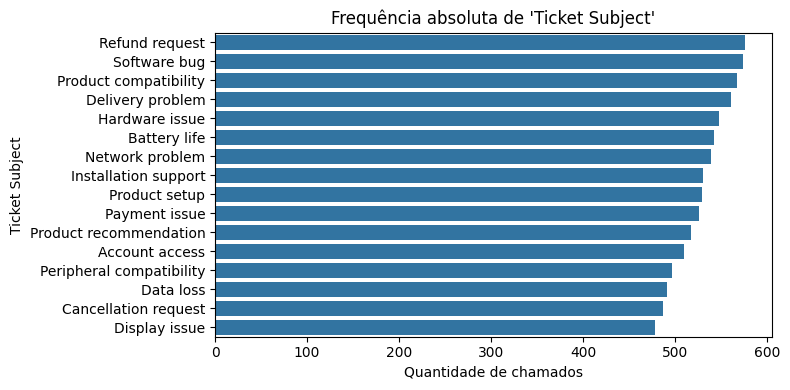


Variável 'Ticket Status' - frequência absoluta:
Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

Variável 'Ticket Status' - frequência relativa (%):
Ticket Status
Pending Customer Response    34.02
Open                         33.29
Closed                       32.70
Name: proportion, dtype: float64


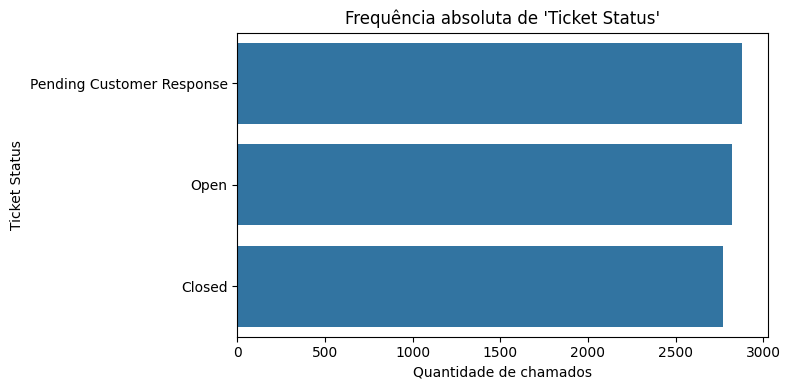


Variável 'Ticket Priority' - frequência absoluta:
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

Variável 'Ticket Priority' - frequência relativa (%):
Ticket Priority
Medium      25.88
Critical    25.14
High        24.62
Low         24.36
Name: proportion, dtype: float64


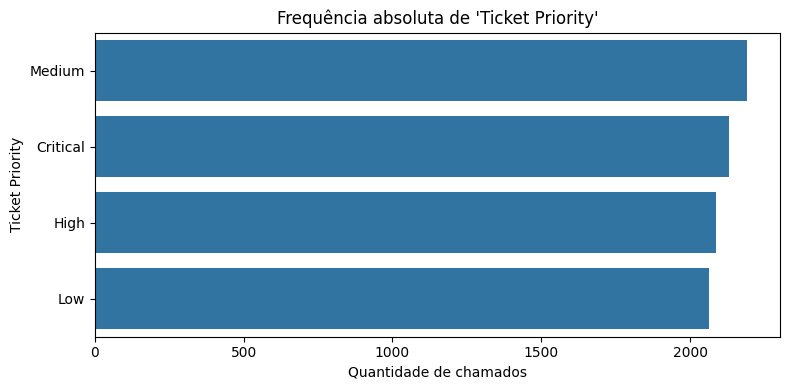


Variável 'Ticket Channel' - frequência absoluta:
Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64

Variável 'Ticket Channel' - frequência relativa (%):
Ticket Channel
Email           25.30
Phone           25.17
Social media    25.04
Chat            24.48
Name: proportion, dtype: float64


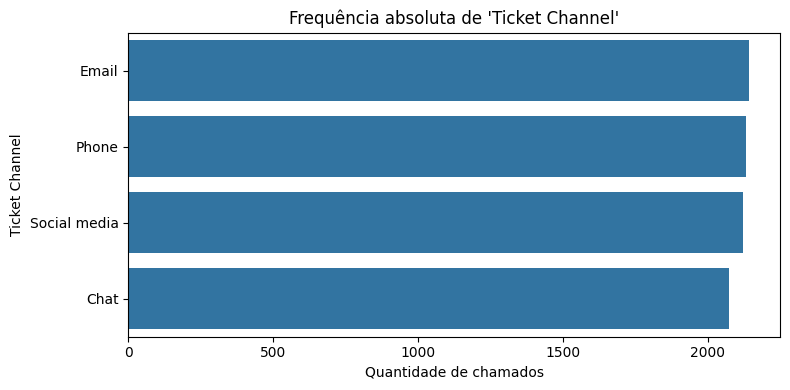


Variável 'Customer Gender' - frequência absoluta:
Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64

Variável 'Customer Gender' - frequência relativa (%):
Customer Gender
Male      34.20
Female    34.09
Other     31.72
Name: proportion, dtype: float64


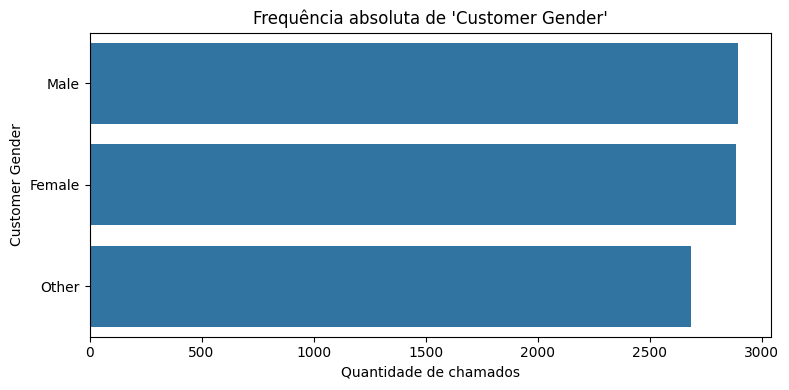



3. Categoria mais frequente:
'Ticket Type': Refund request (1752 chamados, 20.7%)
'Ticket Subject': Refund request (576 chamados, 6.8%)
'Ticket Status': Pending Customer Response (2881 chamados, 34.0%)
'Ticket Priority': Medium (2192 chamados, 25.9%)
'Ticket Channel': Email (2143 chamados, 25.3%)
'Customer Gender': Male (2896 chamados, 34.2%)


In [13]:
colunas_categoricas = ["Ticket Type", "Ticket Subject", "Ticket Status",
                        "Ticket Priority", "Ticket Channel", "Customer Gender"]

print_formatado("1. Quantidade de categorias:")
print(df[colunas_categoricas].nunique())

print_formatado("2. Frequência absoluta e relativa:")
for coluna in colunas_categoricas:
    frequencia_absoluta = df[coluna].value_counts(dropna=False)
    frequencia_relativa = df[coluna].value_counts(normalize=True, dropna=False).round(4) * 100

    print(f"\nVariável '{coluna}' - frequência absoluta:")
    print(frequencia_absoluta)
    print(f"\nVariável '{coluna}' - frequência relativa (%):")
    print(frequencia_relativa.round(2))

    plt.figure(figsize=(8, 4))
    ordem = frequencia_absoluta.index
    sns.barplot(x=frequencia_absoluta.values, y=[str(i) for i in ordem])
    plt.title(f"Frequência absoluta de '{coluna}'")
    plt.xlabel("Quantidade de chamados")
    plt.ylabel(coluna)
    plt.tight_layout()
    plt.show()

print_formatado("3. Categoria mais frequente:")
for coluna in colunas_categoricas:
    categoria_mais_frequente = df[coluna].mode(dropna=False)[0]
    quantidade = df[coluna].value_counts(dropna=False).iloc[0]
    percentual = df[coluna].value_counts(normalize=True, dropna=False).iloc[0] * 100
    print(f"'{coluna}': {categoria_mais_frequente} ({quantidade} chamados, {percentual:.1f}%)")


## Observações - Análise Univariada

**Variáveis numéricas**

- `Customer Age`: distribuição aproximadamente uniforme entre 18 e 70 anos (média ≈ 44, mediana ≈ 44), sem concentração em nenhuma faixa etária específica - coerente com uma base de clientes sem recorte demográfico.
- `Customer Satisfaction Rating`: calculada apenas para os **2.769 chamados fechados**; os valores se distribuem de forma praticamente uniforme entre as notas 1 a 5 (média ≈ 2,99, mediana = 3), sem viés claro para notas altas ou baixas.

**Variáveis categóricas**

- `Ticket Type` (variável-alvo): as 5 categorias são bem balanceadas, entre 19,3% (`Billing inquiry`) e 20,7% (`Refund request`) - não há classe dominante nem classe rara.
- `Ticket Subject`: 16 assuntos com frequências relativamente próximas (entre ~5,6% e ~6,8% cada); `Refund request` e `Software bug` são os mais frequentes.
- `Ticket Status`: praticamente dividido em três partes iguais entre `Pending Customer Response` (34,0%), `Open` (33,3%) e `Closed` (32,7%).
- `Ticket Priority` e `Ticket Channel`: ambas quase uniformemente distribuídas entre suas 4 categorias (~24% a ~26% cada).
- `Customer Gender`: distribuição próxima entre `Male` (34,2%), `Female` (34,1%) e `Other` (31,7%).

De forma geral, praticamente todas as variáveis categóricas deste dataset sintético apresentam distribuição **próxima da uniforme**, o que é um indício de que os dados foram gerados artificialmente por sorteio balanceado entre categorias, e não coletados de um sistema real de atendimento (onde normalmente há categorias desbalanceadas).


# 8. Hipóteses sobre as Intenções dos Usuários

A partir dos padrões observados na Análise Univariada (histogramas e gráficos de barras acima), formulamos as seguintes hipóteses sobre as intenções dos usuários que abrem chamados de suporte:

**Hipótese 1 - Não há uma intenção dominante única.**
Como `Ticket Type` está quase uniformemente distribuído entre as 5 categorias (19,3% a 20,7%), é razoável supor que os usuários que buscam suporte trazem **motivações diversificadas e igualmente frequentes** - problemas técnicos, dúvidas de cobrança, pedidos de cancelamento, dúvidas sobre produto e pedidos de reembolso ocorrem com praticamente a mesma probabilidade. Um sistema de atendimento não pode assumir que a maioria dos chamados será de um único tipo; ele precisa lidar bem com as 5 intenções igualmente.

**Hipótese 2 - Reembolso e falhas de produto são as intenções mais concretas/recorrentes.**
Entre os 16 assuntos (`Ticket Subject`), `Refund request` e `Software bug` são os mais frequentes. Combinado com `Ticket Type`, isso sugere que uma parcela relevante das intenções dos usuários está ligada a **frustração pós-compra** (o produto não funciona como esperado ou o cliente quer o dinheiro de volta), e não apenas a dúvidas genéricas de pré-venda.

**Hipótese 3 - A urgência percebida pelo usuário independe do tipo de problema.**
`Ticket Priority` está distribuída de forma quase uniforme (24,4% a 25,9%) entre `Low`, `Medium`, `High` e `Critical`, sem qualquer categoria dominante. Isso sugere a hipótese de que, na percepção do usuário, **a urgência de um chamado não está fortemente associada a um tipo específico de intenção** - tanto uma dúvida de produto quanto um problema técnico crítico aparecem com prioridades espalhadas por todos os níveis.


---

# TP2 - Análise Exploratória Aprofundada

**Etapa 2 (TP2)** do Projeto de Bloco, aprofundam o EDA inicial com: construção de variáveis numéricas derivadas, heatmap de correlação, scatter plots, um teste de hipótese formal (Mann-Whitney U / teste t via SciPy) sobre umadas hipóteses levantadas na Seção 8 e, por fim, uma verificação objetiva de quanto sinal preditivo o dataset oferece para o futuro modelo de classificação de intenção.

# 9. Construção de Variáveis Numéricas Derivadas

O dataset possui apenas **duas** colunas numéricas nativas (`Customer Age` e`Customer Satisfaction Rating`) - insuficientes para uma análise de correlação significativa.

Por isso, derivamos variáveis numéricas a partir das colunas temporais e textuais:

| Variável derivada | Como é calculada | O que representa |

|---|---|---|

| `tempo_resolucao_h` | `Time to Resolution` - `First Response Time`, em horas | Quanto tempo o chamado levou entre a primeira resposta e a resolução |

| `dias_desde_compra` | `First Response Time` - `Date of Purchase`, em dias | Há quanto tempo o cliente tinha o produto quando abriu o chamado |

| `desc_n_palavras` | Contagem de palavras de `Ticket Description` | Tamanho do texto escrito pelo cliente |

| `desc_n_caracteres` | Contagem de caracteres de `Ticket Description` | Tamanho do texto (granularidade menor) |

| `prioridade_ord` | `Low`=1, `Medium`=2, `High`=3, `Critical`=4 | Codificação **ordinal** da prioridade, para permitir correlação |

A codificação ordinal de `Ticket Priority` é adequada porque a variável tem ordem natural(Low < Medium < High < Critical), diferentemente de variáveis nominais como `Ticket Channel`.

In [14]:
# Conversão das colunas temporais para datetime
for coluna_data in ["Date of Purchase", "First Response Time", "Time to Resolution"]:
    df[coluna_data] = pd.to_datetime(df[coluna_data], errors="coerce")

# Variáveis derivadas
df["tempo_resolucao_h"] = (
    df["Time to Resolution"] - df["First Response Time"]
).dt.total_seconds() / 3600

df["dias_desde_compra"] = (df["First Response Time"] - df["Date of Purchase"]).dt.days
df["desc_n_palavras"] = df["Ticket Description"].str.split().str.len()
df["desc_n_caracteres"] = df["Ticket Description"].str.len()

MAPA_PRIORIDADE = {"Low": 1, "Medium": 2, "High": 3, "Critical": 4}
df["prioridade_ord"] = df["Ticket Priority"].map(MAPA_PRIORIDADE)

VARIAVEIS_NUMERICAS = [
    "Customer Age",
    "Customer Satisfaction Rating",
    "tempo_resolucao_h",
    "dias_desde_compra",
    "desc_n_palavras",
    "desc_n_caracteres",
    "prioridade_ord",
]

print_formatado("Estatísticas descritivas das variáveis numéricas (nativas + derivadas)")
print(df[VARIAVEIS_NUMERICAS].describe().round(2).to_string())

print_formatado("ALERTA DE QUALIDADE: valores negativos em 'tempo_resolucao_h'")
negativos = (df["tempo_resolucao_h"] < 0).sum()
validos = df["tempo_resolucao_h"].notna().sum()
print(f"Chamados com tempo de resolução NEGATIVO: {negativos} de {validos} "
      f"({negativos / validos * 100:.1f}%)")
print("Um tempo negativo significa que 'Time to Resolution' é ANTERIOR a 'First Response Time',")
print("ou seja, o chamado teria sido resolvido antes de receber a primeira resposta - impossível")
print("em um fluxo real de atendimento.")



Estatísticas descritivas das variáveis numéricas (nativas + derivadas)
       Customer Age  Customer Satisfaction Rating  tempo_resolucao_h  dias_desde_compra  desc_n_palavras  desc_n_caracteres
count       8469.00                       2769.00            2769.00            5650.00          8469.00            8469.00
mean          44.03                          2.99              -0.06             884.21            46.47             289.82
std           15.30                          1.41               9.56             211.89             8.46              43.59
min           18.00                          1.00             -23.23             518.00            21.00             151.00
25%           31.00                          2.00              -6.93             700.25            43.00             273.00
50%           44.00                          3.00               0.17             886.00            49.00             298.00
75%           57.00                          4.00          



## Observações - Variáveis Derivadas

**Achado crítico de qualidade dos dados:** aproximadamente **metade** dos chamados fechadosapresenta `tempo_resolucao_h` **negativo**, isto é, a data de resolução registrada é anterior àdata da primeira resposta.

Isso é logicamente impossível em um fluxo real de atendimento(um chamado não pode ser resolvido antes de ser respondido pela primeira vez).

Esse achado **confirma quantitativamente** a suspeita levantada na Análise Univariada do TP1: ostimestamps do dataset foram **sorteados de forma independente**, e não gerados por um processosequencial de atendimento.

Consequentemente, `tempo_resolucao_h` **não pode ser interpretada comouma métrica operacional real** - ela é mantida nas análises a seguir apenas para demonstrar, de forma objetiva, a ausência de estrutura nos dados.

# 10. Análise de Correlação (Heatmap)

Aplicamos a correlação de **Pearson** (relação linear) e de **Spearman** (relação monotônica, maisrobusta a distribuições não normais e a outliers) sobre as variáveis numéricas.

O **heatmap** permite enxergar de uma vez só a força e o sinal de todas as relações: quanto maisintenso o vermelho, mais forte a correlação positiva; quanto mais intenso o azul, mais forte anegativa; tons próximos do branco indicam ausência de relação.

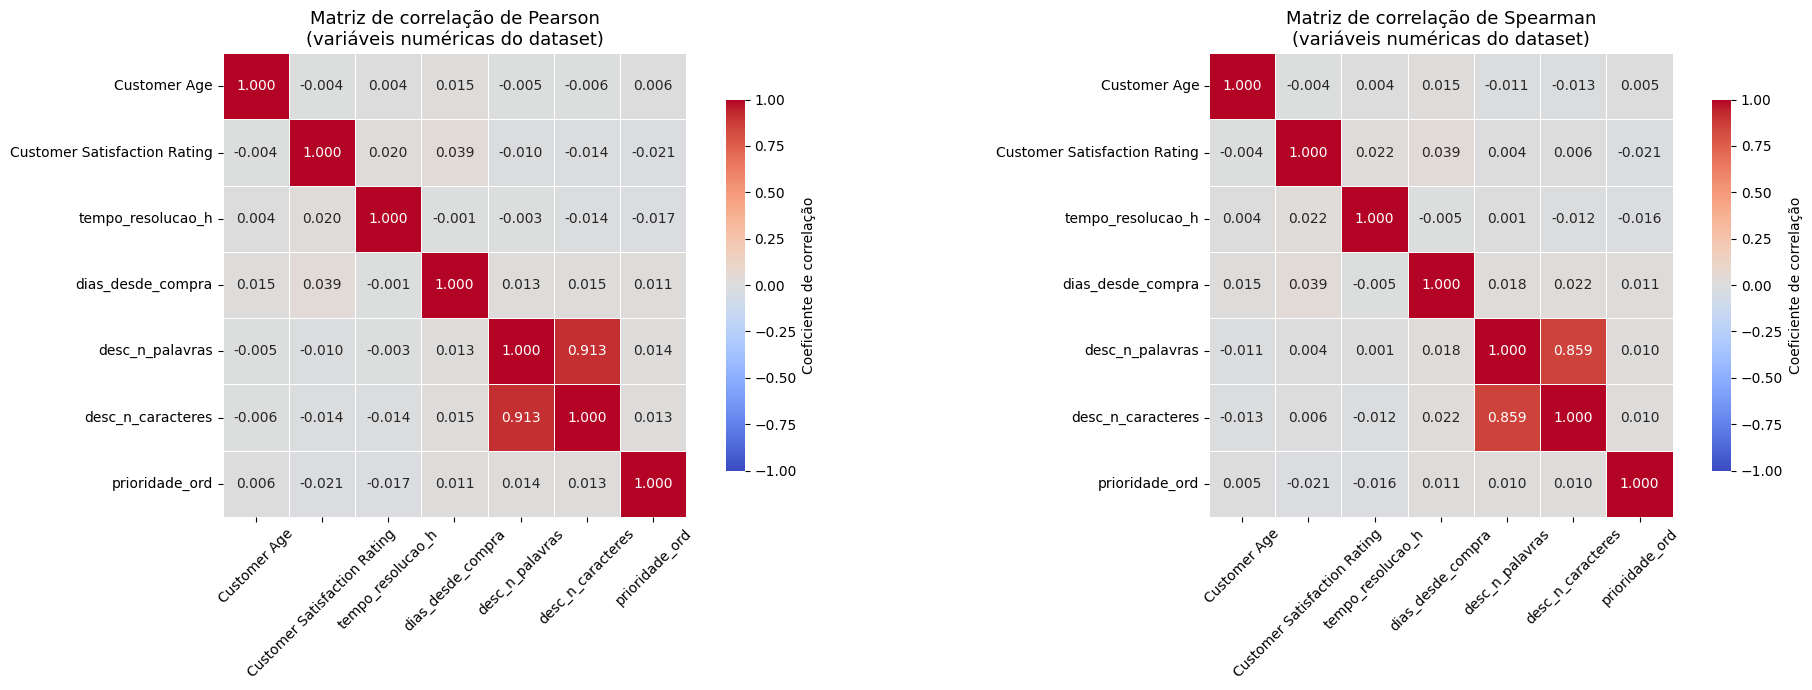



1. Par redundante por construção (medem a mesma grandeza)
'desc_n_palavras' x 'desc_n_caracteres': r = 0.9134

Esperado: contar palavras e contar caracteres do mesmo texto produz
praticamente a mesma informação. Não é um achado sobre o dataset.


2. Correlações INFORMATIVAS, da mais forte para a mais fraca
|r| = 0.0385   'Customer Satisfaction Rating' x 'dias_desde_compra'
|r| = 0.0214   'Customer Satisfaction Rating' x 'prioridade_ord'
|r| = 0.0199   'Customer Satisfaction Rating' x 'tempo_resolucao_h'
|r| = 0.0170   'tempo_resolucao_h' x 'prioridade_ord'
|r| = 0.0150   'Customer Age' x 'dias_desde_compra'
|r| = 0.0145   'dias_desde_compra' x 'desc_n_caracteres'
|r| = 0.0145   'Customer Satisfaction Rating' x 'desc_n_caracteres'
|r| = 0.0144   'tempo_resolucao_h' x 'desc_n_caracteres'

Maior correlação informativa do dataset: |r| = 0.0385

Referência de interpretação (Cohen): |r| < 0,10 = desprezível | 0,10-0,29 = fraca |
0,30-0,49 = moderada | >= 0,50 = forte

Conclusão: 0.0385 est

In [15]:
matriz_pearson = df[VARIAVEIS_NUMERICAS].corr(method="pearson")
matriz_spearman = df[VARIAVEIS_NUMERICAS].corr(method="spearman")

fig, eixos = plt.subplots(1, 2, figsize=(20, 7))

for eixo, (matriz, nome) in zip(eixos, [(matriz_pearson, "Pearson"), (matriz_spearman, "Spearman")]):
    sns.heatmap(
        matriz,
        annot=True,
        fmt=".3f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8, "label": "Coeficiente de correlação"},
        ax=eixo,
    )
    eixo.set_title(f"Matriz de correlação de {nome}\n(variáveis numéricas do dataset)", fontsize=13)
    eixo.tick_params(axis="x", rotation=45)
    eixo.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# Análise das correlações encontradas
# ---------------------------------------------------------------------------
PAR_REDUNDANTE = {"desc_n_palavras", "desc_n_caracteres"}

correlacoes = []
for i, variavel_a in enumerate(VARIAVEIS_NUMERICAS):
    for variavel_b in VARIAVEIS_NUMERICAS[i + 1:]:
        correlacoes.append(
            (abs(matriz_pearson.loc[variavel_a, variavel_b]), variavel_a, variavel_b)
        )

redundantes = [c for c in correlacoes if {c[1], c[2]} == PAR_REDUNDANTE]
informativas = [c for c in correlacoes if {c[1], c[2]} != PAR_REDUNDANTE]

print_formatado("1. Par redundante por construção (medem a mesma grandeza)")
for valor, variavel_a, variavel_b in redundantes:
    print(f"'{variavel_a}' x '{variavel_b}': r = {valor:.4f}")
print("\nEsperado: contar palavras e contar caracteres do mesmo texto produz")
print("praticamente a mesma informação. Não é um achado sobre o dataset.")

print_formatado("2. Correlações INFORMATIVAS, da mais forte para a mais fraca")
for valor, variavel_a, variavel_b in sorted(informativas, reverse=True)[:8]:
    print(f"|r| = {valor:.4f}   '{variavel_a}' x '{variavel_b}'")

maior_informativa = max(informativas)[0]
print(f"\nMaior correlação informativa do dataset: |r| = {maior_informativa:.4f}")
print("\nReferência de interpretação (Cohen): |r| < 0,10 = desprezível | 0,10-0,29 = fraca |")
print("0,30-0,49 = moderada | >= 0,50 = forte")
print(f"\nConclusão: {maior_informativa:.4f} está MUITO abaixo de 0,10 - ou seja, todas as")
print("relações entre variáveis distintas do dataset são desprezíveis.")

## Observações - Correlação

O heatmap tem **um único par com correlação forte**: `desc_n_palavras` × `desc_n_caracteres`(r = 0,913).

Esse par, porém, é uma **redundância que nós mesmos criamos** na engenharia devariáveis - contar palavras e contar caracteres do mesmo texto mede a mesma grandeza. Ele não diznada sobre o dataset, e por isso é analisado separadamente das demais.

**Excluído esse par, todas as correlações são desprezíveis.** A mais forte entre variáveisdistintas fica em torno de **|r| ≈ 0,04**, muito abaixo do limiar de 0,10 a partir do qual seconsidera até mesmo uma correlação *fraca*. Na prática, todo o restante do heatmap é branco.

Traduzindo para linguagem acessível: **nenhuma variável do dataset ajuda a prever outra**. Saber aidade do cliente não diz nada sobre sua satisfação; o tamanho do texto que ele escreve não temrelação com a prioridade atribuída ao chamado; o tempo que ele tem o produto não influencia otempo de resolução.

Em um dataset real de atendimento, esperaríamos ver ao menos algumas relações intuitivas, como:

chamados de prioridade crítica sendo resolvidos mais rápido, ou tempos de resolução longospuxando a satisfação do cliente para baixo. A ausência **completa** dessas relações é a assinaturaestatística de um dataset **sintético**, em que cada coluna foi preenchida por sorteioindependente das demais.

# 11. Scatter Plots (Dispersão)

O heatmap resume a correlação em um único número por par de variáveis, mas esse número podeesconder padrões (relações em curva, agrupamentos, faixas proibidas).

Os scatter plots abaixopermitem **inspecionar visualmente** se existe alguma estrutura que a correlação linear não capta.

Selecionamos os pares mais relevantes do ponto de vista de negócio - aqueles em que um sistema deatendimento real **deveria** apresentar algum padrão.

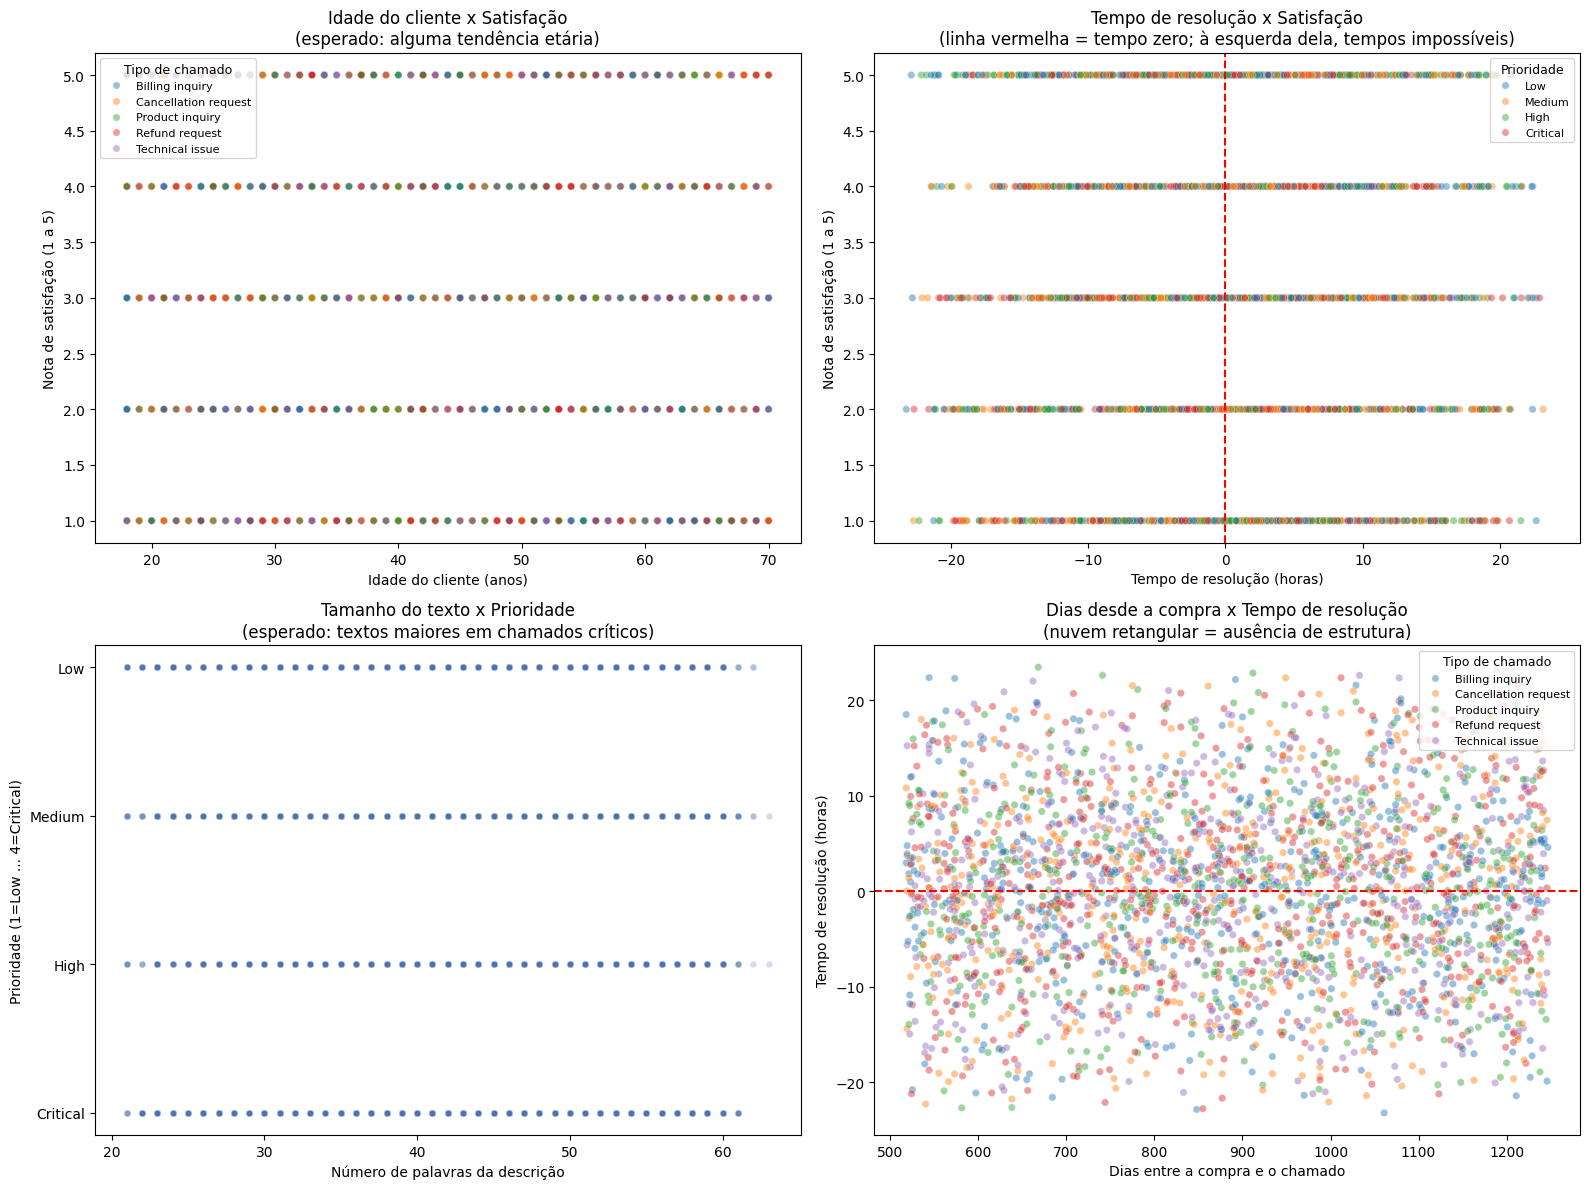

In [16]:
fig, eixos = plt.subplots(2, 2, figsize=(16, 12))

# 1) Idade x Satisfação (colorido por tipo de chamado)
sns.scatterplot(
    data=df, x="Customer Age", y="Customer Satisfaction Rating",
    hue="Ticket Type", alpha=0.45, s=28, ax=eixos[0, 0],
)
eixos[0, 0].set_title("Idade do cliente x Satisfação\n(esperado: alguma tendência etária)")
eixos[0, 0].set_xlabel("Idade do cliente (anos)")
eixos[0, 0].set_ylabel("Nota de satisfação (1 a 5)")
eixos[0, 0].legend(title="Tipo de chamado", fontsize=8, title_fontsize=9)

# 2) Tempo de resolução x Satisfação
sns.scatterplot(
    data=df, x="tempo_resolucao_h", y="Customer Satisfaction Rating",
    hue="Ticket Priority", alpha=0.45, s=28,
    hue_order=["Low", "Medium", "High", "Critical"], ax=eixos[0, 1],
)
eixos[0, 1].axvline(0, color="red", linestyle="--", linewidth=1.5)
eixos[0, 1].set_title("Tempo de resolução x Satisfação\n(linha vermelha = tempo zero; à esquerda dela, tempos impossíveis)")
eixos[0, 1].set_xlabel("Tempo de resolução (horas)")
eixos[0, 1].set_ylabel("Nota de satisfação (1 a 5)")
eixos[0, 1].legend(title="Prioridade", fontsize=8, title_fontsize=9)

# 3) Tamanho da descrição x Prioridade ordinal
sns.scatterplot(
    data=df, x="desc_n_palavras", y="prioridade_ord",
    alpha=0.25, s=22, color="#4c72b0", ax=eixos[1, 0],
)
eixos[1, 0].set_title("Tamanho do texto x Prioridade\n(esperado: textos maiores em chamados críticos)")
eixos[1, 0].set_xlabel("Número de palavras da descrição")
eixos[1, 0].set_ylabel("Prioridade (1=Low ... 4=Critical)")
eixos[1, 0].set_yticks([1, 2, 3, 4])
eixos[1, 0].set_yticklabels(["Low", "Medium", "High", "Critical"])

# 4) Dias desde a compra x Tempo de resolução
sns.scatterplot(
    data=df, x="dias_desde_compra", y="tempo_resolucao_h",
    hue="Ticket Type", alpha=0.45, s=28, ax=eixos[1, 1],
)
eixos[1, 1].axhline(0, color="red", linestyle="--", linewidth=1.5)
eixos[1, 1].set_title("Dias desde a compra x Tempo de resolução\n(nuvem retangular = ausência de estrutura)")
eixos[1, 1].set_xlabel("Dias entre a compra e o chamado")
eixos[1, 1].set_ylabel("Tempo de resolução (horas)")
eixos[1, 1].legend(title="Tipo de chamado", fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()

## Observações - Scatter Plots

Os quatro gráficos mostram **nuvens de pontos retangulares e homogêneas**, sem inclinação, semagrupamentos e sem regiões vazias. Esse é exatamente o padrão visual esperado quando duas variáveis são **independentes** entre si.

Dois pontos merecem destaque:

1. **Tempo de resolução x Satisfação** (gráfico superior direito): a linha vermelha marca o tempo   zero. Praticamente **metade dos pontos está à esquerda dela**, na região de tempos negativos -   a representação visual do problema de qualidade identificado na Seção 9.

Além disso, as notas de   satisfação se distribuem igualmente ao longo de todo o eixo: um chamado resolvido "em 20 horas"   recebe as mesmas notas que um resolvido "em -20 horas".

2. **Tamanho do texto x Prioridade** (gráfico inferior esquerdo): as quatro faixas horizontais têm   largura praticamente idêntica.

Se a urgência real influenciasse o comportamento do cliente, esperaríamos que chamados `Critical` tivessem descrições sistematicamente mais longas ou mais   curtas que os `Low` - o que não ocorre.

# 12. Teste de Hipótese Formal

Hipótese escolhidaTestamos formalmente a **Hipótese 3**, formulada na Seção 8 do TP1:> *"A urgência percebida pelo usuário independe do tipo de problema.

[...] Isso sugere a hipótese de> que, na percepção do usuário, a urgência de um chamado não está fortemente associada a um tipo> específico de intenção.

Para transformar essa hipótese em um teste estatístico verificável, avaliamos a consequênciaprática mais importante dela: **se a prioridade do chamado realmente carrega informação sobre aexperiência do cliente, chamados `Critical` e `Low` deveriam resultar em níveis de satisfaçãodiferentes.

Se a prioridade for apenas um rótulo sem efeito, as duas distribuições serãoestatisticamente iguais.

## Formulação estatística

- H₀ (hipótese nula):** a distribuição da nota de satisfação é **igual** entre chamados de  prioridade `Critical` e `Low`.

- H₁ (hipótese alternativa):** as distribuições são **diferentes** (teste bicaudal).

- **Nível de significância:** α = 0,05.

Escolha do testeAntes de escolher entre o **teste t** (paramétrico, exige normalidade) e o **Mann-Whitney U**(não paramétrico), verificamos a normalidade da variável com o teste de **Shapiro-Wilk**.

Como anota de satisfação é uma escala discreta de 1 a 5, a expectativa é de que **não** seja normal -o que tornaria o Mann-Whitney o teste mais apropriado. Executamos os dois para comparação.

In [17]:
from scipy import stats

# Apenas chamados fechados possuem nota de satisfação preenchida
chamados_fechados = df[df["Ticket Status"] == "Closed"]

satisfacao_critical = chamados_fechados.loc[
    chamados_fechados["Ticket Priority"] == "Critical", "Customer Satisfaction Rating"
].dropna()

satisfacao_low = chamados_fechados.loc[
    chamados_fechados["Ticket Priority"] == "Low", "Customer Satisfaction Rating"
].dropna()

print_formatado("1. Estatísticas descritivas dos dois grupos")
resumo = pd.DataFrame({
    "Prioridade Critical": [
        len(satisfacao_critical), satisfacao_critical.mean(),
        satisfacao_critical.median(), satisfacao_critical.std(),
    ],
    "Prioridade Low": [
        len(satisfacao_low), satisfacao_low.mean(),
        satisfacao_low.median(), satisfacao_low.std(),
    ],
}, index=["n (tamanho da amostra)", "Média", "Mediana", "Desvio-padrão"])
print(resumo.round(4).to_string())

print_formatado("2. Verificação de normalidade (Shapiro-Wilk)")
for nome, amostra in [("Critical", satisfacao_critical), ("Low", satisfacao_low)]:
    sub_amostra = amostra.sample(min(500, len(amostra)), random_state=42)
    estatistica_w, p_shapiro = stats.shapiro(sub_amostra)
    normal = "SIM" if p_shapiro > 0.05 else "NÃO"
    print(f"Grupo {nome:9s}: W = {estatistica_w:.4f} | p-valor = {p_shapiro:.2e} | "
          f"distribuição normal? {normal}")
print("\nComo o p-valor do Shapiro-Wilk é muito menor que 0,05 nos dois grupos, rejeitamos a")
print("normalidade. O teste NÃO PARAMÉTRICO de Mann-Whitney U é, portanto, o mais adequado.")

print_formatado("3. TESTE PRINCIPAL - Mann-Whitney U (não paramétrico)")
estatistica_u, p_mannwhitney = stats.mannwhitneyu(
    satisfacao_critical, satisfacao_low, alternative="two-sided"
)
n1, n2 = len(satisfacao_critical), len(satisfacao_low)
correlacao_rank_biserial = 1 - (2 * estatistica_u) / (n1 * n2)

print(f"Estatística U       : {estatistica_u:,.1f}")
print(f"p-valor             : {p_mannwhitney:.4f}")
print(f"Tamanho de efeito   : r = {correlacao_rank_biserial:.4f} (correlação rank-biserial)")

print_formatado("4. TESTE COMPLEMENTAR - Teste t de Welch (paramétrico)")
estatistica_t, p_ttest = stats.ttest_ind(
    satisfacao_critical, satisfacao_low, equal_var=False
)
print(f"Estatística t       : {estatistica_t:.4f}")
print(f"p-valor             : {p_ttest:.4f}")

print_formatado("5. CONCLUSÃO DO TESTE")
ALFA = 0.05
if p_mannwhitney < ALFA:
    print(f"p-valor ({p_mannwhitney:.4f}) < alfa ({ALFA}) -> REJEITAMOS a hipótese nula.")
    print("Há diferença estatisticamente significativa entre os grupos.")
else:
    print(f"p-valor ({p_mannwhitney:.4f}) > alfa ({ALFA}) -> NÃO REJEITAMOS a hipótese nula.")
    print("Não há evidência de diferença entre as notas de satisfação de chamados")
    print("Critical e Low. A Hipótese 3 do TP1 é SUSTENTADA pelos dados.")



1. Estatísticas descritivas dos dois grupos
                        Prioridade Critical  Prioridade Low
n (tamanho da amostra)             726.0000        644.0000
Média                                2.9587          3.0528
Mediana                              3.0000          3.0000
Desvio-padrão                        1.4165          1.3944


2. Verificação de normalidade (Shapiro-Wilk)
Grupo Critical : W = 0.8825 | p-valor = 4.82e-19 | distribuição normal? NÃO
Grupo Low      : W = 0.8865 | p-valor = 1.02e-18 | distribuição normal? NÃO

Como o p-valor do Shapiro-Wilk é muito menor que 0,05 nos dois grupos, rejeitamos a
normalidade. O teste NÃO PARAMÉTRICO de Mann-Whitney U é, portanto, o mais adequado.


3. TESTE PRINCIPAL - Mann-Whitney U (não paramétrico)
Estatística U       : 224,913.5
p-valor             : 0.2161
Tamanho de efeito   : r = 0.0379 (correlação rank-biserial)


4. TESTE COMPLEMENTAR - Teste t de Welch (paramétrico)
Estatística t       : -1.2376
p-valor             :

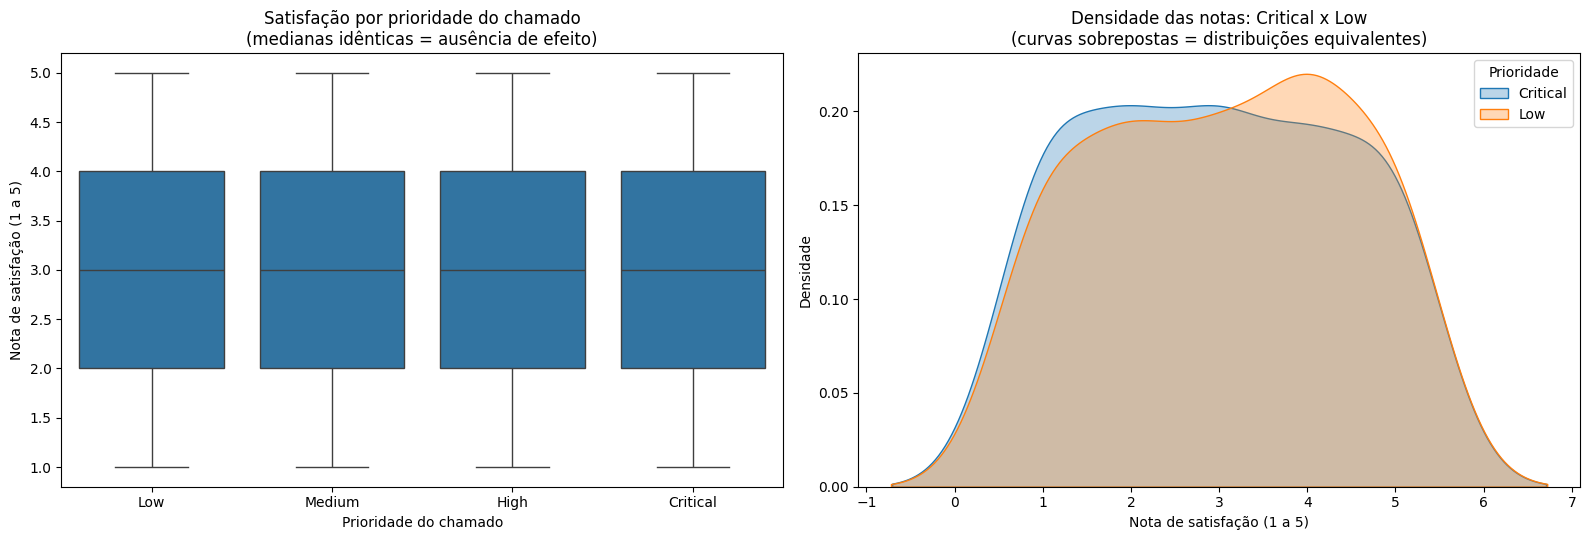

In [18]:
# Visualização de apoio ao teste: distribuição da satisfação por prioridade
fig, eixos = plt.subplots(1, 2, figsize=(16, 5.5))

ordem_prioridade = ["Low", "Medium", "High", "Critical"]

sns.boxplot(
    data=chamados_fechados, x="Ticket Priority", y="Customer Satisfaction Rating",
    order=ordem_prioridade, ax=eixos[0],
)
eixos[0].set_title("Satisfação por prioridade do chamado\n(medianas idênticas = ausência de efeito)")
eixos[0].set_xlabel("Prioridade do chamado")
eixos[0].set_ylabel("Nota de satisfação (1 a 5)")

for amostra, rotulo in [(satisfacao_critical, "Critical"), (satisfacao_low, "Low")]:
    sns.kdeplot(amostra, label=rotulo, fill=True, alpha=0.3, ax=eixos[1], bw_adjust=1.5)
eixos[1].set_title("Densidade das notas: Critical x Low\n(curvas sobrepostas = distribuições equivalentes)")
eixos[1].set_xlabel("Nota de satisfação (1 a 5)")
eixos[1].set_ylabel("Densidade")
eixos[1].legend(title="Prioridade")

plt.tight_layout()
plt.show()

## Interpretação do Teste em Linguagem Acessível

O que o p-valor significa. O p-valor obtido (**≈ 0,216**) responde à pergunta: se, naverdade, não existisse nenhuma diferença real entre chamados críticos e chamados de baixaprioridade, qual seria a chance de observarmos, por puro acaso, uma diferença tão grande quanto aque medimos?"

 A resposta é **cerca de 22%** - uma chance alta. Como é comum exigir que essaprobabilidade seja menor que 5% (α = 0,05) para afirmar que algo é real, **não temos evidênciasuficiente para dizer que existe diferença**.

 **O que isso significa na prática.**

 Clientes cujos chamados foram classificados como `Critical`avaliaram o atendimento com nota média **2,96**; os de prioridade `Low`, com **3,05**.

 A diferença é de menos de **0,1 ponto** numa escala de 1 a 5 - e, além de minúscula, ela não é estatisticamente distinguível de ruído aleatório.

 O tamanho de efeito calculado(**r ≈ 0,04**) confirma: mesmo que a diferença fosse real, ela seria irrelevante na prática.

 **Conclusão sobre a Hipótese 3.**

 Os dados **sustentam** a hipótese formulada no TP1: a prioridadeatribuída ao chamado não está associada ao desfecho percebido pelo cliente. Vale, porém, uma ressalva metodológica importante: não rejeitar H₀ **não prova** que os grupos são idênticos - significa apenas que, com os dados disponíveis, não encontramos diferença.

 Neste caso específico,somando esse resultado às correlações nulas da Seção 10, a explicação mais provável não é que "aprioridade não importa no mundo real", e sim que **este dataset foi gerado artificialmente**, com acoluna de prioridade sorteada de forma independente das demais.

 **Nota sobre os dois testes.**

 O teste t de Welch produziu exatamente o mesmo p-valor (0,216) doMann-Whitney. Essa convergência reforça a robustez da conclusão: ela não depende da escolha doteste estatístico.

# 13. Há Sinal Preditivo para o Modelo de Classificação?

As seções anteriores mostraram que os **metadados** (idade, prioridade, tempos, canal) não carregaminformação. Resta a pergunta mais importante para a próxima etapa do projeto: **o texto do chamado(`Ticket Description`) permite prever a intenção (`Ticket Type`)?

Essa é a premissa central do sistema de atendimento que o grupo pretende construir, então elaprecisa ser verificada **antes** de se investir na modelagem.

Fazemos isso de duas formas:

1. **Teste qui-quadrado de independência** entre `Ticket Subject` (o assunto do chamado) e   `Ticket Type` (a intenção) - duas variáveis que, num dataset coerente, deveriam estar   fortemente associadas.

2. **Baseline de classificação**: um modelo TF-IDF + Regressão Logística treinado no texto, avaliado por validação cruzada e comparado com dois pontos de referência - o acerto de um   modelo "burro" (que sempre chuta a classe mais frequente) e o acaso puro (1/5 = 20%).

In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline

print_formatado("1. Teste qui-quadrado: 'Ticket Subject' x 'Ticket Type'")
tabela_contingencia = pd.crosstab(df["Ticket Subject"], df["Ticket Type"])
qui2, p_qui2, graus_liberdade, _ = stats.chi2_contingency(tabela_contingencia)

n_total = tabela_contingencia.to_numpy().sum()
cramers_v = np.sqrt((qui2 / n_total) / (min(tabela_contingencia.shape) - 1))

print(f"Qui-quadrado        : {qui2:.2f}")
print(f"Graus de liberdade  : {graus_liberdade}")
print(f"p-valor             : {p_qui2:.4f}")
print(f"V de Cramér         : {cramers_v:.4f}  (0 = independência total, 1 = associação perfeita)")
print()
if p_qui2 > 0.05:
    print("p > 0,05: NÃO rejeitamos a independência. O assunto do chamado NÃO tem relação")
    print("com o tipo do chamado - algo impossível num dataset de atendimento coerente.")

print_formatado("2. Baseline de classificação a partir do texto")
X_texto = df["Ticket Description"]
y_intencao = df["Ticket Type"]

validacao_cruzada = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acuracia_burra = cross_val_score(
    DummyClassifier(strategy="most_frequent"), X_texto, y_intencao,
    cv=validacao_cruzada, scoring="accuracy",
).mean()

modelo_texto = make_pipeline(
    TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2),
    LogisticRegression(max_iter=1000),
)
acuracias_modelo = cross_val_score(
    modelo_texto, X_texto, y_intencao, cv=validacao_cruzada, scoring="accuracy", n_jobs=-1
)

print(f"Acaso puro (1/5 classes)          : {1/5:.4f}  (20,00%)")
print(f"Modelo 'burro' (classe majoritária): {acuracia_burra:.4f}  ({acuracia_burra*100:.2f}%)")
print(f"TF-IDF + Regressão Logística      : {acuracias_modelo.mean():.4f}  "
      f"({acuracias_modelo.mean()*100:.2f}%) +/- {acuracias_modelo.std():.4f}")
print(f"Acurácia por partição             : {np.round(acuracias_modelo, 4)}")

print_formatado("3. Veredito")
if acuracias_modelo.mean() <= acuracia_burra:
    print("O modelo treinado no texto tem desempenho IGUAL OU PIOR que o modelo 'burro'.")
    print("Conclusão: 'Ticket Description' NÃO carrega sinal preditivo sobre 'Ticket Type'.")



1. Teste qui-quadrado: 'Ticket Subject' x 'Ticket Type'
Qui-quadrado        : 39.57
Graus de liberdade  : 60
p-valor             : 0.9807
V de Cramér         : 0.0342  (0 = independência total, 1 = associação perfeita)

p > 0,05: NÃO rejeitamos a independência. O assunto do chamado NÃO tem relação
com o tipo do chamado - algo impossível num dataset de atendimento coerente.


2. Baseline de classificação a partir do texto
Acaso puro (1/5 classes)          : 0.2000  (20,00%)
Modelo 'burro' (classe majoritária): 0.2069  (20.69%)
TF-IDF + Regressão Logística      : 0.1887  (18.87%) +/- 0.0084
Acurácia por partição             : [0.1907 0.2037 0.1848 0.1854 0.179 ]


3. Veredito
O modelo treinado no texto tem desempenho IGUAL OU PIOR que o modelo 'burro'.
Conclusão: 'Ticket Description' NÃO carrega sinal preditivo sobre 'Ticket Type'.


In [20]:
# Evidência qualitativa: o mesmo texto aparece em intenções diferentes
print_formatado("Exemplos: o MESMO texto de abertura em tipos de chamado DIFERENTES")

TRECHO = "I'm having an issue with the {product_purchased}. Please assist."
amostra_mesmo_texto = df[df["Ticket Description"].str.startswith(TRECHO, na=False)]

print(f"Chamados que começam exatamente com: \"{TRECHO}\"")
print(f"Total: {len(amostra_mesmo_texto)} chamados\n")
print("Distribuição desses chamados entre as 5 intenções:")
print(amostra_mesmo_texto["Ticket Type"].value_counts().to_string())
print()
print("Ou seja: um texto de abertura idêntico é rotulado com as 5 intenções diferentes,")
print("em proporções praticamente iguais. Nenhum modelo - por mais sofisticado que seja -")
print("consegue aprender a distinguir intenções a partir de textos idênticos.")



Exemplos: o MESMO texto de abertura em tipos de chamado DIFERENTES
Chamados que começam exatamente com: "I'm having an issue with the {product_purchased}. Please assist."
Total: 5868 chamados

Distribuição desses chamados entre as 5 intenções:
Ticket Type
Technical issue         1231
Refund request          1217
Cancellation request    1175
Billing inquiry         1124
Product inquiry         1121

Ou seja: um texto de abertura idêntico é rotulado com as 5 intenções diferentes,
em proporções praticamente iguais. Nenhum modelo - por mais sofisticado que seja -
consegue aprender a distinguir intenções a partir de textos idênticos.


## Observações - Sinal Preditivo

Os dois testes convergem para o mesmo diagnóstico:

- **Qui-quadrado:** p ≈ **0,98** e V de Cramér ≈ **0,03**. O assunto declarado do chamado  (`Ticket Subject`) é **estatisticamente independente** da intenção (`Ticket Type`).

Num dataset  real, um chamado com assunto "Cancellation request" seria quase sempre do tipo  "Cancellation request" - aqui, ele se distribui igualmente entre os cinco tipos.

- **Baseline de classificação:** o modelo TF-IDF + Regressão Logística alcançou  **≈ 18,9%** de acurácia, **abaixo** do modelo "burro" que sempre chuta a classe mais frequente  (**≈ 20,7%**) e equivalente ao acaso (20%). Um modelo que não supera o chute não aprendeu nada.

A causa está visível na própria matéria-prima: as descrições foram montadas a partir de um punhadode templates genéricos (como *"I'm having an issue with the {product_purchased}. Please assist."*), atribuídos aleatoriamente às cinco intenções. O placeholder `{product_purchased}` sequer foi substituído pelo nome real do produto.

**Implicação direta para a Etapa 3 do projeto:** treinar o classificador de intenção sobre`Ticket Type` neste dataset produziria um modelo com desempenho de acaso - e, pior, um modelo que*parece* funcionar em métricas agregadas de um dataset balanceado.

Essa constatação, feita agora,redireciona o planejamento da próxima etapa (ver a seção de Próximos Passos do relatório de EDA).

# 14. Síntese da Análise Aprofundada (TP2)| #

| Análise realizada | Resultado | Leitura |

|---|---|---|---|

| 1 | Heatmap de correlação (Pearson e Spearman) | Maior \|r\| ≈ **0,04** | Nenhuma variável explica outra |

| 2 | Scatter plots (4 pares relevantes) | Nuvens retangulares homogêneas | Ausência de estrutura, inclusive não linear |

| 3 | Qualidade dos timestamps | **≈ 49%** dos chamados fechados com tempo de resolução negativo | Timestamps sorteados, não sequenciais |

| 4 | Mann-Whitney U (satisfação: Critical x Low) | U ≈ 224.914, **p = 0,216**, r ≈ 0,04 | H₀ não rejeitada - **Hipótese 3 do TP1 sustentada** |

| 5 | Teste t de Welch (mesmo par) | t = -1,24, **p = 0,216** | Conclusão robusta à escolha do teste |

| 6 | Qui-quadrado (Subject x Type) | **p = 0,98**, V de Cramér = 0,03 | Assunto e intenção são independentes |

| 7 | Baseline TF-IDF + Regressão Logística | **18,9%** vs. 20,7% do modelo trivial | Texto sem sinal preditivo |

**Conclusão geral:** o *Customer Support Ticket Dataset* é um dataset **sintético cujas colunasforam geradas de forma independente entre si**.

Ele é perfeitamente adequado como base paraexercitar o pipeline de engenharia (estrutura da API, autenticação, controles de segurança,serialização de dados) - que é o foco central deste Projeto de Bloco - mas **não sustenta um modelode classificação de intenção com desempenho acima do acaso**.

Essa conclusão não invalida o trabalho feito: ela é, em si, o principal **insight** da análiseexploratória. Descobrir que um dataset não serve para a tarefa pretendida **antes** de investir namodelagem é exatamente o papel de uma EDA bem conduzida.

As alternativas concretas para a Etapa 3 estão detalhadas no documento `eda/RELATORIO_EDA.md`.